In [1]:
import os 
import math 
import re 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
# for preprocessing and Feature engineering
from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)
from sklearn.feature_selection import(
    SelectKBest,
    SelectPercentile,
    RFE,
    RFECV,
    VarianceThreshold
)

from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    Normalizer,
    PolynomialFeatures,
    OrdinalEncoder,
    LabelEncoder,
    KBinsDiscretizer,
    FunctionTransformer
)

# Model Selection and Evaluation

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    confusion_matrix,
    r2_score,
    classification_report,
    f1_score,
    recall_score,
    explained_variance_score,
    precision_score
)

# For Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    SGDRegressor,
    PassiveAggressiveRegressor
)

from sklearn.tree import (
    DecisionTreeRegressor,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor
)

from sklearn.svm import (
    SVR,
    LinearSVR

)

from sklearn.neighbors import (
    KNeighborsRegressor,
)

from sklearn.neural_network import (
    MLPRegressor,
    _multilayer_perceptron
)


# For Classification
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)

from sklearn.svm import (
    SVC,
    LinearSVC,
    NuSVC
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)

from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)




In [2]:
df = pd.read_csv(
    "../data/processed/nepali_food_meal_classified.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (620, 14)


,sn,food_name,protein,fat,carbs,fiber,calories,calcium,iron,vitamin_c,breakfast,lunch,dinner,food_name_clean
0,1,Amaranth seed,9.4,7.17,68.1,2.2,375.0,37.0,5.2,58.94,1,0,0,amaranth seed
1,2,Barely,11.5,1.30,69.6,3.9,336.0,26.0,1.7,0.00,0,1,0,barely
2,3,Buck wheat (whole),10.3,2.40,65.1,8.6,323.0,64.0,15.5,0.00,1,0,0,buck wheat (whole)
3,4,Bajra,11.6,5.00,67.5,1.2,361.0,42.0,8.0,0.00,1,0,0,bajra
4,5,Bamboo seed,13.1,1.10,75.9,0.9,367.0,37.0,6.4,58.95,0,1,1,bamboo seed


In [3]:
print(df.shape)
print(df.info())

(620, 14)
<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sn               620 non-null    int64  
 1   food_name        620 non-null    str    
 2   protein          620 non-null    float64
 3   fat              620 non-null    float64
 4   carbs            620 non-null    float64
 5   fiber            620 non-null    float64
 6   calories         620 non-null    float64
 7   calcium          620 non-null    float64
 8   iron             620 non-null    float64
 9   vitamin_c        620 non-null    float64
 10  breakfast        620 non-null    int64  
 11  lunch            620 non-null    int64  
 12  dinner           620 non-null    int64  
 13  food_name_clean  620 non-null    str    
dtypes: float64(8), int64(4), str(2)
memory usage: 67.9 KB
None


In [4]:
print(df[["breakfast", "lunch", "dinner"]].sum())

breakfast    225
lunch        321
dinner       344
dtype: int64


In [5]:
multiple_categories = (
    (df["breakfast"] + df["lunch"] + df["dinner"]) > 1
)

print(
    "Foods belonging to multiple meal categories:",
    multiple_categories.sum()
)

Foods belonging to multiple meal categories: 302


Total breakfast foods: 225
Foods available for clustering: 225
Features used: ['protein', 'fat', 'carbs']


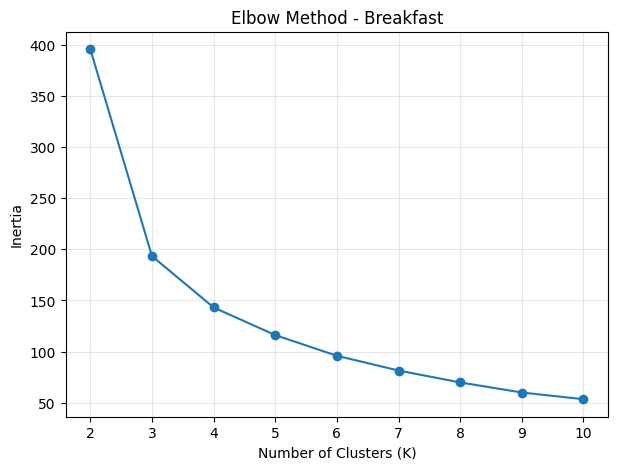

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
# 1. SELECT ONLY BREAKFAST FOODS
breakfast = df[df["breakfast"] == 1].copy()

print("Total breakfast foods:", len(breakfast))


# 2. SELECT NUTRITIONAL FEATURES
features = [
    "protein",
    "fat",
    "carbs"
]

X = breakfast[features].dropna()

print("Foods available for clustering:", len(X))
print("Features used:", features)


# 3. STANDARDIZE
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 4. ELBOW METHOD

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# 5. PLOT ELBOW CURVE

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Breakfast")

plt.xticks(range(2, 11))
plt.grid(alpha=0.3)

plt.show()

0.48887074647350814
0.5869901936907874
0.5821539785878967
0.5802580459938068
0.5892684015551799
0.597642881080524
0.5813613554250061
0.5249450684331124
0.5364617469636961


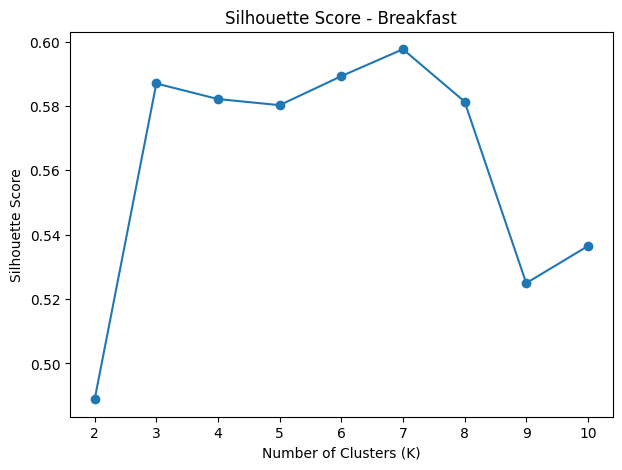

In [8]:
# 5.Silhouette Score
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(score)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Breakfast')
plt.show()

K-Means clustering completed.
Number of clusters: 3

Cluster distribution:
Cluster
0    108
1     92
2     25
Name: count, dtype: int64

PCA explained variance ratio:
[0.52513289 0.34675147]
Total variance explained: 0.871884357589869


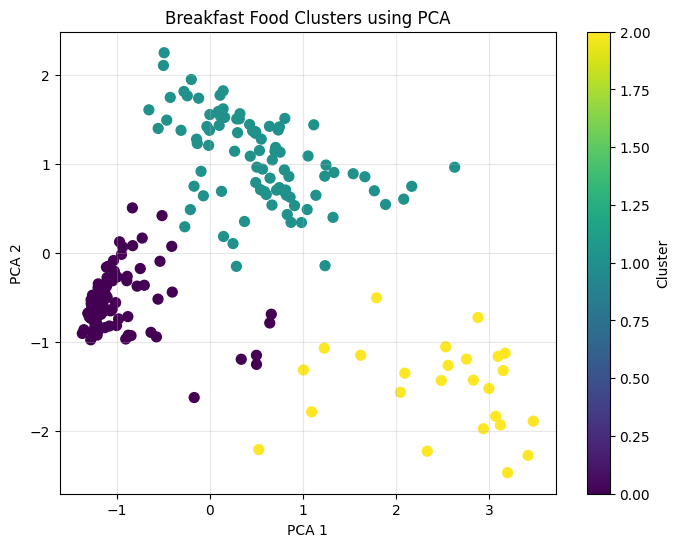

In [15]:
# 6. CHOOSE K AND TRAIN K-MEANS

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
print("Number of clusters:", k)


# 7. ADD CLUSTER LABELS

# Copy the breakfast dataframe so we can safely add labels
breakfast_clustered = breakfast.loc[X.index].copy()

breakfast_clustered["Cluster"] = clusters

print("\nCluster distribution:")
print(
    breakfast_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

# 8. PCA - REDUCE 3 FEATURES TO 2 DIMENSIONS

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

# 9. PLOT PCA CLUSTERS

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Breakfast Food Clusters using PCA")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)

plt.show()

In [17]:

# CLUSTER NUTRITIONAL PROFILE

cluster_profile = (
    breakfast_clustered
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

print("\nCluster Nutritional Profile:")
print(cluster_profile)


Cluster Nutritional Profile:
         protein    fat  carbs
Cluster                       
0           2.27   1.43  13.60
1          10.22   7.31  67.31
2          18.85  41.03  17.64


In [18]:

#CLUSTER SIZE

cluster_counts = (
    breakfast_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nFoods per cluster:")
print(cluster_counts)


Foods per cluster:
Cluster
0    108
1     92
2     25
Name: count, dtype: int64


Total lunch foods: 321
Foods available for clustering: 321


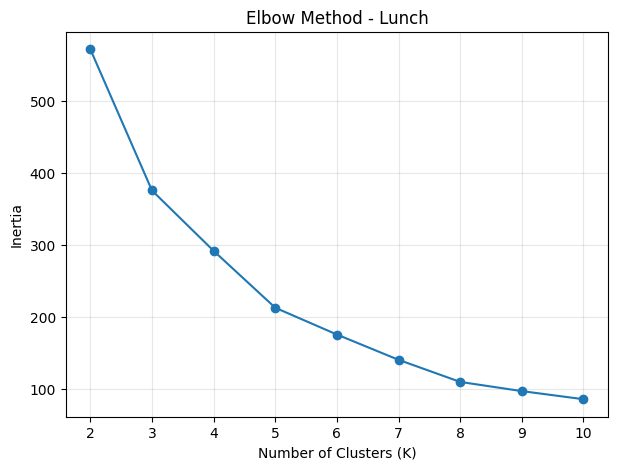

In [19]:

# LUNCH K-MEANS CLUSTERING

# 1. Select only lunch foods
lunch = df[df["lunch"] == 1].copy()

print("Total lunch foods:", len(lunch))


# 2. Select nutritional features
features = ["protein", "fat", "carbs"]

X = lunch[features].dropna()

print("Foods available for clustering:", len(X))


# 3. Standardize nutritional features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 4. Elbow Method
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# 5. Plot Elbow Curve
plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Lunch")

plt.grid(alpha=0.3)

plt.show()

K = 2, Silhouette Score = 0.5276
K = 3, Silhouette Score = 0.5819
K = 4, Silhouette Score = 0.6033
K = 5, Silhouette Score = 0.5871
K = 6, Silhouette Score = 0.5986
K = 7, Silhouette Score = 0.6088
K = 8, Silhouette Score = 0.6160
K = 9, Silhouette Score = 0.6212
K = 10, Silhouette Score = 0.5160


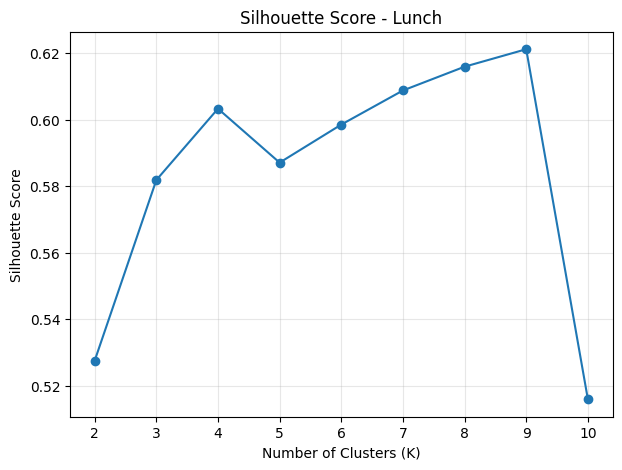

In [20]:

# SILHOUETTE SCORE

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )


# Plot silhouette scores
plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Lunch")

plt.grid(alpha=0.3)

plt.show()

In [23]:
# LUNCH K-MEANS CLUSTERING

# 1. Select only lunch foods
lunch = df[df["lunch"] == 1].copy()

# 2. Select nutritional features
features = ["protein", "fat", "carbs"]

X = lunch[features].dropna()

print("Total lunch foods:", len(lunch))
print("Foods used for clustering:", len(X))


# 3. Standardize the nutritional features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 4. Train K-Means
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)


# 5. Add cluster labels to lunch dataframe
lunch.loc[X.index, "Cluster"] = clusters

lunch["Cluster"] = lunch["Cluster"].astype("Int64")


# 6. Display cluster distribution
print("\n==================================================")
print("LUNCH CLUSTER DISTRIBUTION")
print("==================================================")

print(
    lunch["Cluster"]
    .value_counts()
    .sort_index()
)


# 7. Calculate silhouette score
score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:", round(score, 4))


# 8. Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

cluster_centers.index.name = "Cluster"

print("\n==================================================")
print("LUNCH CLUSTER CENTERS")
print("==================================================")

print(
    cluster_centers.round(2)
)


# 9. Add number of foods in each cluster
cluster_summary = cluster_centers.copy()

cluster_summary["food_count"] = (
    lunch["Cluster"]
    .value_counts()
    .sort_index()
)

print("\n==================================================")
print("LUNCH CLUSTER SUMMARY")
print("==================================================")

print(
    cluster_summary.round(2)
)


# 10. Show sample foods from each cluster
print("\n==================================================")
print("SAMPLE FOODS BY CLUSTER")
print("==================================================")

for cluster in sorted(lunch["Cluster"].dropna().unique()):

    foods = lunch[
        lunch["Cluster"] == cluster
    ]["food_name"].head(10).tolist()

    print(f"\nCluster {cluster}:")
    print(", ".join(foods))

Total lunch foods: 321
Foods used for clustering: 321

LUNCH CLUSTER DISTRIBUTION
Cluster
0    191
1     39
2     60
3     31
Name: count, dtype: Int64

Silhouette Score: 0.6033

LUNCH CLUSTER CENTERS
         protein    fat  carbs
Cluster                       
0           3.70   0.81  11.29
1           8.07   1.84  79.16
2          22.85   2.88  48.02
3          14.73  21.09  38.37

LUNCH CLUSTER SUMMARY
         protein    fat  carbs  food_count
Cluster                                   
0           3.70   0.81  11.29         191
1           8.07   1.84  79.16          39
2          22.85   2.88  48.02          60
3          14.73  21.09  38.37          31

SAMPLE FOODS BY CLUSTER

Cluster 0:
Maize green (tender), Sprout bean, Tofu (Soybean product), Amaranth (spined), Amaranth (tender), Asparagus (Kurilo), Agathi, Aniseed leaves, Bethel leaves, Beet green

Cluster 1:
Barely, Bamboo seed, Maize dry (Murali), Maize granular, Rice Parboiled (hand pounded), Rice (raw) (Milled), Rice (R

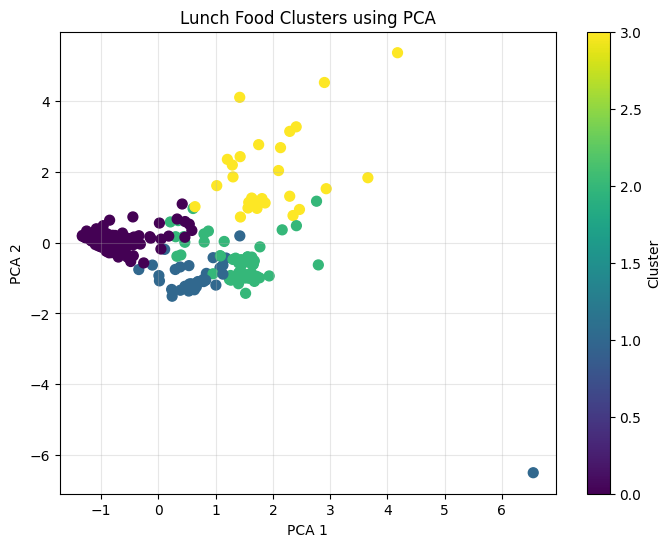


PCA explained variance:
[0.52106516 0.29236181]
Total explained variance: 0.8134


In [24]:
# PCA VISUALIZATION

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Lunch Food Clusters using PCA")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)

plt.show()


# Explained variance
print("\nPCA explained variance:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Total dinner foods: 344
Foods used for clustering: 344


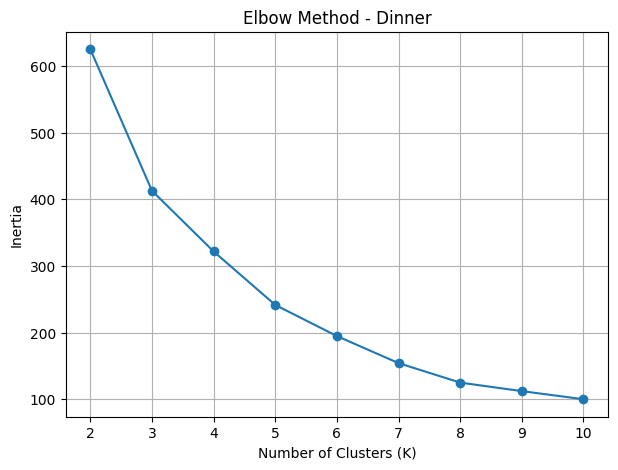

K = 2, Silhouette Score = 0.5161
K = 3, Silhouette Score = 0.5724
K = 4, Silhouette Score = 0.5930
K = 5, Silhouette Score = 0.5812
K = 6, Silhouette Score = 0.5961
K = 7, Silhouette Score = 0.6092
K = 8, Silhouette Score = 0.6157
K = 9, Silhouette Score = 0.6145
K = 10, Silhouette Score = 0.5195


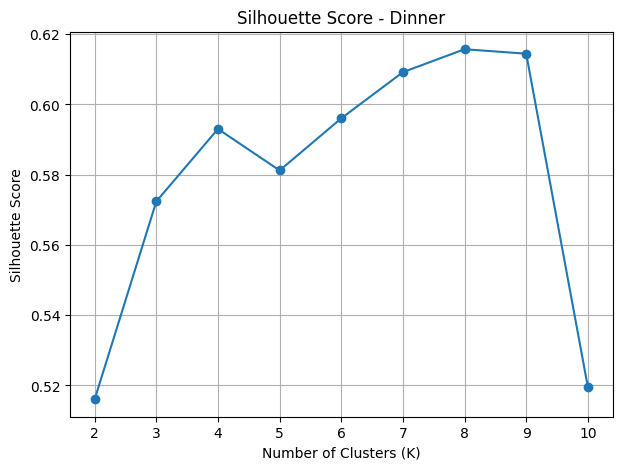

In [30]:

# 1. Select only dinner foods

dinner = df[df["dinner"] == 1].copy()

print("Total dinner foods:", len(dinner))


# 2. Select nutritional features

features = [
    "protein",
    "fat",
    "carbs"
]

X = dinner[features].dropna()

print("Foods used for clustering:", len(X))


# 3. Standardize nutritional features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 4. Elbow Method

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(7, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Dinner")

plt.grid(True)

plt.show()


# 5. Silhouette Score

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )


# 6. Plot Silhouette Scores

plt.figure(figsize=(7, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Dinner")

plt.grid(True)

plt.show()

DINNER CLUSTER DISTRIBUTION
Cluster
0     60
1    202
2     35
3     47
Name: count, dtype: Int64

Silhouette Score: 0.593

DINNER CLUSTER NUTRITIONAL PROFILE
         protein    fat  carbs
Cluster                       
0          22.78   2.54  44.53
1           3.49   0.80  10.71
2          15.04  21.36  36.78
3           8.35   2.19  75.92

PCA explained variance ratio:
[0.51938368 0.29369191]
Total variance explained: 0.8131


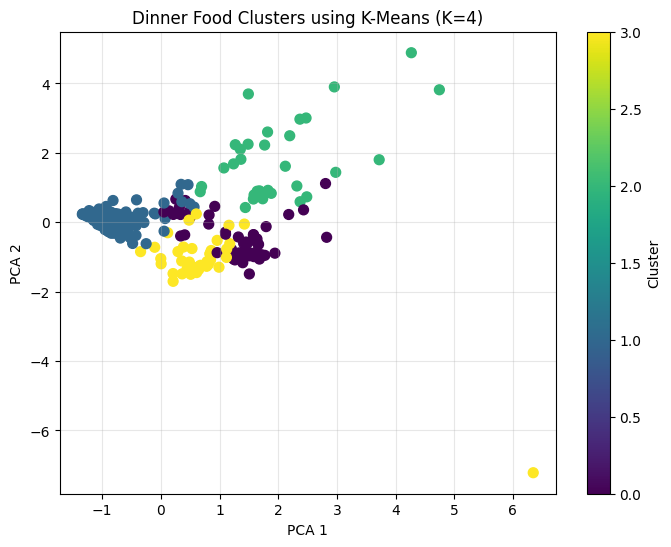

In [31]:
# DINNER K-MEANS CLUSTERING
k = 4

kmeans_dinner = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans_dinner.fit_predict(X_scaled)

# Add cluster labels
dinner.loc[X.index, "Cluster"] = clusters

dinner["Cluster"] = dinner["Cluster"].astype("Int64")

# Cluster distribution


print("==================================================")
print("DINNER CLUSTER DISTRIBUTION")
print("==================================================")

print(
    dinner["Cluster"]
    .value_counts()
    .sort_index()
)

# Silhouette score for selected K

score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:", round(score, 4))


# Cluster nutritional profile

cluster_profile = (
    dinner
    .groupby("Cluster")[features]
    .mean()
)

print("\n==================================================")
print("DINNER CLUSTER NUTRITIONAL PROFILE")
print("==================================================")

print(cluster_profile.round(2))


# PCA


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


# PCA visualization

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Dinner Food Clusters using K-Means (K=4)")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)

plt.show()

In [32]:
# FINAL K-MEANS CLUSTERING

# 1. Configuration

FEATURES = [
    "protein",
    "fat",
    "carbs"
]

CLUSTER_SETTINGS = {
    "breakfast": 3,
    "lunch": 4,
    "dinner": 4
}

RANDOM_STATE = 42
N_INIT = 10


# 2. Create cluster columns

df["breakfast_cluster"] = pd.NA
df["lunch_cluster"] = pd.NA
df["dinner_cluster"] = pd.NA


# 3. Store trained models and scalers

models = {}
scalers = {}
cluster_results = {}


# 4. Train one K-Means model for each meal

for meal, k in CLUSTER_SETTINGS.items():

    print("\n" + "=" * 60)
    print(f"{meal.upper()} CLUSTERING")
    print("=" * 60)

    # Select foods belonging to this meal
    meal_data = df[df[meal] == 1].copy()

    print("Total foods:", len(meal_data))

    # Select nutritional features
    X = meal_data[FEATURES].copy()

    # Remove rows with missing nutritional values
    valid_mask = X.notna().all(axis=1)

    X = X[valid_mask]
    meal_data = meal_data.loc[X.index]

    print("Foods used for clustering:", len(X))

    # Standardization
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # Train K-Means

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )

    clusters = kmeans.fit_predict(X_scaled)

    # Save cluster labels to main dataframe

    cluster_column = f"{meal}_cluster"

    df.loc[X.index, cluster_column] = clusters

    # Calculate silhouette score

    silhouette = silhouette_score(
        X_scaled,
        clusters
    )

    # Save model and scaler

    models[meal] = kmeans
    scalers[meal] = scaler

    # Cluster distribution

    distribution = pd.Series(clusters).value_counts().sort_index()

    print("\nNumber of clusters:", k)

    print("\nSilhouette Score:")
    print(round(silhouette, 4))

    print("\nCluster Distribution:")
    print(distribution)

    # Cluster nutritional profile

    meal_data["cluster"] = clusters

    cluster_profile = (
        meal_data
        .groupby("cluster")[FEATURES]
        .mean()
        .round(2)
    )

    print("\nCluster Nutritional Profile:")
    print(cluster_profile)

    # Save result for later use

    cluster_results[meal] = {
        "model": kmeans,
        "scaler": scaler,
        "silhouette": silhouette,
        "distribution": distribution,
        "profile": cluster_profile
    }


print("\n" + "=" * 60)
print("FINAL CLUSTERING COMPLETED")
print("=" * 60)


BREAKFAST CLUSTERING
Total foods: 225
Foods used for clustering: 225

Number of clusters: 3

Silhouette Score:
0.587

Cluster Distribution:
0    108
1     92
2     25
Name: count, dtype: int64

Cluster Nutritional Profile:
         protein    fat  carbs
cluster                       
0           2.27   1.43  13.60
1          10.22   7.31  67.31
2          18.85  41.03  17.64

LUNCH CLUSTERING
Total foods: 321
Foods used for clustering: 321

Number of clusters: 4

Silhouette Score:
0.6033

Cluster Distribution:
0    191
1     39
2     60
3     31
Name: count, dtype: int64

Cluster Nutritional Profile:
         protein    fat  carbs
cluster                       
0           3.70   0.81  11.29
1           8.07   1.84  79.16
2          22.85   2.88  48.02
3          14.73  21.09  38.37

DINNER CLUSTERING
Total foods: 344
Foods used for clustering: 344

Number of clusters: 4

Silhouette Score:
0.593

Cluster Distribution:
0     60
1    202
2     35
3     47
Name: count, dtype: int64

Clus

In [33]:
import os
import joblib

# Create model directory
os.makedirs("../models", exist_ok=True)

# Save K-Means models
joblib.dump(
    models["breakfast"],
    "../models/breakfast_kmeans.joblib"
)

joblib.dump(
    models["lunch"],
    "../models/lunch_kmeans.joblib"
)

joblib.dump(
    models["dinner"],
    "../models/dinner_kmeans.joblib"
)

# Save scalers
joblib.dump(
    scalers["breakfast"],
    "../models/breakfast_scaler.joblib"
)

joblib.dump(
    scalers["lunch"],
    "../models/lunch_scaler.joblib"
)

joblib.dump(
    scalers["dinner"],
    "../models/dinner_scaler.joblib"
)

print("All K-Means models and scalers saved successfully.")

All K-Means models and scalers saved successfully.


In [34]:

# SAVE FINAL CLUSTERED DATASET

output_path = "../data/processed/nepali_food_clustered.csv"

df.to_csv(
    output_path,
    index=False
)

print("Clustered dataset saved successfully.")
print("Saved to:", output_path)
print("Dataset shape:", df.shape)

Clustered dataset saved successfully.
Saved to: ../data/processed/nepali_food_clustered.csv
Dataset shape: (620, 17)


In [35]:

# INSPECT CLUSTER CONTENT

for meal in ["breakfast", "lunch", "dinner"]:

    cluster_column = f"{meal}_cluster"

    print("\n" + "=" * 70)
    print(f"{meal.upper()} CLUSTERS")
    print("=" * 70)

    meal_foods = df[df[meal] == 1].copy()

    for cluster in sorted(
        meal_foods[cluster_column].dropna().unique()
    ):

        foods = meal_foods[
            meal_foods[cluster_column] == cluster
        ]["food_name"].tolist()

        print(f"\nCluster {int(cluster)} ({len(foods)} foods):")

        print(", ".join(foods))


BREAKFAST CLUSTERS

Cluster 0 (108 foods):
Buckwheat leaves, Brussels sprouts, Jack fruit tender, Mango green, Banana rhizome, Mango ginger, Apple, Amala ( big), Amala (small), Apricot fresh, Avocado, Bael fruit, Bael sarbet, Banana ripe, Banyan tree figs, Bamboo fruit, Cashew fruit, Dates, Fresh, Figs, Grape- pale green variety, Grape-Blue variety, Grape fruit( trumph) juice, Guava , hill, Guava, country, Ground apple, Jackfruit   ripe seed, Jambu fruit, Kussum fruit, Lapsi, Lemon(Nibuwa), Lemon sweet, Lemon Juice, Lichi, Lich ,bastard, Lime, Lime, sweet, malta, Lakuch, Laruat, Mango, Ripe, Mango, Ripe / Bombay, Mango, Ripe / Malda, Mango, Ripe / Sukutara, Mango, Ripe / Dashari, Mango, Ripe / Jarda, Mango, Ripe / Kalkatiya, Mango, Ripe / Fajali, Mango, Ripe / Amrapali, Mango, Ripe / Chausa, Mango, Ripe / Mallika, Mahua, ripe, Mulberry, Melon water, Neem fruit, Junar, Orange, Orange juice, Papaya   (ripe), Persimon with peel, Persimon without peel, Peaches, Phalsa, Pinapple, Pipal tre